In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike_timemax  # TIME-MAXIMIZED VERSION
# import modeselectoralt
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 3/12     # Total time
print(f"Using dt = {dt} seconds, T = {T} years")

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 1.8  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

# NOTE: change verbose argument for debugging
# Using n-indexed mode selection
loglike_obj = loglike_timemax.LogLikeTimeMax(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

print('Done initializing loglike class.')
print('Calculating SNR...')
data = loglike_obj.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)
print("Setting up log_density and prior functions...")

def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        try:
            loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        except Exception:
            loglike = -np.inf
        log_likes[i] = loglike

    return log_likes

def prior_transform(u):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8,1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]

    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    return transformed

def inverse_prior_transform(params):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]

    params = np.asarray(params)
    u = np.zeros_like(params)

    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])

    return u



print('Done setting up log-likelihood and prior.')

Using dt = 10 seconds, T = 0.25 years
Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
Calculating SNR...
SNR calculated: 5.942134448355127
Setting up log_density and prior functions...
Done setting up log-likelihood and prior.


In [3]:
sampler = parismc.Sampler.load_state('./search/intrinsic_ffunc_3mth_snr32_paris1_1/sampler_state.pkl')

In [4]:
sampler_9 = parismc.Sampler.load_state('./search/intrinsic_ffunc_3mth_snr32_paris1_9_seed/sampler_state.pkl')

In [5]:
sampler_9.config

SamplerConfig(seed=2, merge_confidence=0.9, alpha=1000, trail_size=1000, boundary_limiting=True, use_beta=True, integral_num=100000, gamma=500, exclude_scale_z=inf, use_pool=False, n_pool=10, stop_on_merge=False, merge_type='single', cov_jitter=1e-10, keep_dead_processes=True, debug=False)

In [6]:
sampler.config

SamplerConfig(seed=None, merge_confidence=0.9, alpha=1000, trail_size=1000, boundary_limiting=True, use_beta=False, integral_num=100000, gamma=500, exclude_scale_z=inf, use_pool=False, n_pool=10, stop_on_merge=False, merge_type='single', cov_jitter=1e-10, keep_dead_processes=True, debug=False)

In [7]:
sampler.element_num_list

[5000]

In [8]:
points  = sampler.searched_points_list[0]
logdens = sampler.searched_log_densities_list[0]

In [9]:
points[:3901]

array([[0.537553  , 0.642705  , 0.549253  , 0.373063  , 0.397031  ],
       [0.53756087, 0.64271595, 0.54924315, 0.37305137, 0.39704231],
       [0.53754599, 0.64269731, 0.54925608, 0.37305516, 0.39702619],
       ...,
       [0.27962843, 0.24905414, 0.05822396, 0.69116064, 0.69613003],
       [0.80726485, 0.73330704, 0.98406153, 0.13050186, 0.81926881],
       [0.2189553 , 0.27857162, 0.06024289, 0.52451828, 0.52163143]],
      shape=(3901, 5))

In [10]:
logdens[:3901]

array([2.02502927, 2.02448539, 2.01759835, ..., 0.01534611, 0.1028284 ,
       0.00625598], shape=(3901,))

In [11]:
prior_transform(points[np.argmax(logdens)].reshape(1,-1))

array([[6.0287495 , 1.12244275, 0.68211059, 9.12435594, 0.31883426]])

In [12]:
sampler_anneal7 = parismc.Sampler.load_state('./search/intrinsic_ffunc_3mth_snr32_anneal7/sampler_state.pkl')

In [13]:
points_anneal7  = sampler_anneal7.searched_points_list[0][:3900]
logdens_anneal7 = sampler_anneal7.searched_log_densities_list[0][:3900]

In [14]:
len(points_anneal7)

3900

In [15]:
maxpt_anneal7 = prior_transform(points_anneal7[np.argmax(logdens_anneal7)].reshape(1,-1))
maxld_anneal7 = log_density(maxpt_anneal7)
maxld_anneal7

array([2.92401059])

In [16]:
sampler_5seed = parismc.Sampler.load_state('./search/intrinsic_ffunc_3mth_snr32_paris1_5_seed/sampler_state.pkl')

In [17]:
sampler.now_covariances

[array([[ 0.06176978,  0.00182774,  0.00349099, -0.00387599,  0.00082357],
        [ 0.00182774,  0.07612409,  0.00390862,  0.01214081, -0.00472933],
        [ 0.00349099,  0.00390862,  0.08585764,  0.01038404, -0.0123366 ],
        [-0.00387599,  0.01214081,  0.01038404,  0.08207651,  0.01714665],
        [ 0.00082357, -0.00472933, -0.0123366 ,  0.01714665,  0.06624379]])]

In [35]:
sampler_12seed = parismc.Sampler.load_state('./search/intrinsic_ffunc_3mth_snr32_paris1_12_seed/sampler_state.pkl')

In [36]:
sampler_12seed.config

SamplerConfig(seed=48, merge_confidence=0.9, alpha=1000, trail_size=1000, boundary_limiting=True, use_beta=True, integral_num=100000, gamma=500, exclude_scale_z=inf, use_pool=False, n_pool=10, stop_on_merge=False, merge_type='single', cov_jitter=1e-10, keep_dead_processes=True, debug=False)

# run plot

In [18]:
import re                                                                                                                                                                          
import matplotlib.pyplot as plt

logfile = './search/logs/intrinsic_ffunc_3mth_snr32_paris1_1.err'                                                                                                                           

iters, nprocs = [], []                                                                                                                                                             
seen = set()    

with open(logfile) as f:
    content = f.read()

# Split on \r since tqdm uses carriage returns                                                                                                                                     
segments = content.replace('\r', '\n').split('\n')
                                                                                                                                                                                    
for seg in segments:                                                                                                                                                               
    m = re.search(r'n_proc:\s*(\d+).*?\|\s*(\d+)/\d+', seg)
    if m:                                                                                                                                                                          
        np_ = int(m.group(1))                                                                                                                                                    
        it  = int(m.group(2))                                                                                                                                                      
        if it not in seen:
            seen.add(it)                                                                                                                                                           
            iters.append(it)                                                                                                                                                     
            nprocs.append(np_)

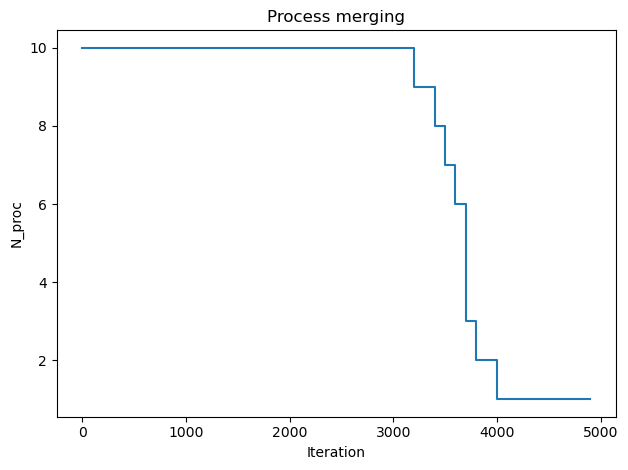

In [19]:
plt.figure()                                                                                                                                                                       
plt.step(iters, nprocs, where='post')
plt.xlabel('Iteration')                                                                                                                                                            
plt.ylabel('N_proc')
plt.title('Process merging')
plt.tight_layout()
plt.show()

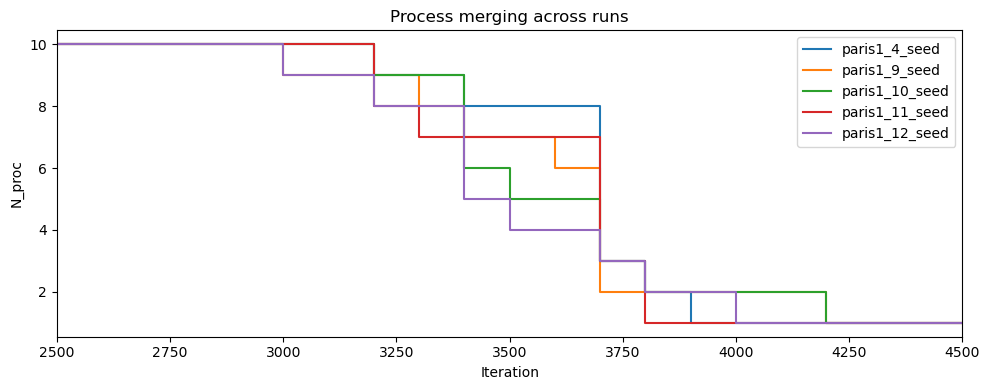

In [24]:
files = {          
    # 'paris1_1': './search/logs/intrinsic_ffunc_3mth_snr32_paris1_1.err',                                                                                                                                                            
    # 'paris1_6': './search/logs/intrinsic_ffunc_3mth_snr32_paris1_6.err',                                                                                                                    
    # 'paris1_7': './search/logs/intrinsic_ffunc_3mth_snr32_paris1_7.err', 
    # 'paris1_8': './search/logs/intrinsic_ffunc_3mth_snr32_paris1_8.err', 
    'paris1_4_seed': './search/logs/intrinsic_ffunc_3mth_snr32_paris1_4_seed.err',                                                                                                                    
    # 'paris1_5_seed':  './search/logs/intrinsic_ffunc_3mth_snr32_paris1_5_seed.err',
    # 'paris1_6_seed':  './search/logs/intrinsic_ffunc_3mth_snr32_paris1_6_seed.err',
    'paris1_9_seed':  './search/logs/intrinsic_ffunc_3mth_snr32_paris1_9_seed.err',
    'paris1_10_seed':  './search/logs/intrinsic_ffunc_3mth_snr32_paris1_10_seed.err',
    'paris1_11_seed':  './search/logs/intrinsic_ffunc_3mth_snr32_paris1_11_seed.err',
    'paris1_12_seed':  './search/logs/intrinsic_ffunc_3mth_snr32_paris1_12_seed.err',

}                                                                                                                                                                                  
                                                                                                                                                                                    
fig, ax = plt.subplots(figsize=(10, 4))                                                                                                                                            
                                                                                                                                                                                
for label, path in files.items():                                                                                                                                                  
    with open(path) as f:
        content = f.read()                                                                                                                                                         
                                                                                                                                                                                
    iters, nprocs = [], []
    seen = set()
    for seg in content.replace('\r', '\n').split('\n'):                                                                                                                            
        m = re.search(r'n_proc:\s*(\d+).*?\|\s*(\d+)/\d+', seg)                                                                                                                    
        if m:                                                                                                                                                                      
            np_ = int(m.group(1))                                                                                                                                                  
            it  = int(m.group(2))                                                                                                                                                  
            if it not in seen:                                                                                                                                                   
                seen.add(it)                                                                                                                                                       
                iters.append(it)                                                                                                                                                 
                nprocs.append(np_)
                                                                                                                                                                                    
    ax.step(iters, nprocs, where='post', label=label)

ax.set_xlabel('Iteration')                                                                                                                                                       
ax.set_ylabel('N_proc')
ax.set_title('Process merging across runs')                                                                                                                                        
ax.legend()
plt.xlim(2500,4500)
plt.tight_layout()                                                                                                                                                                 
# plt.savefig('nproc_vs_iter_all.png', dpi=150)                                                                                                                                    
plt.show()  

# corner plot

In [25]:
base = '/nfs/home/svu/e1498138/localgit/FEWNEW/work/search'                                                                                                                        
runs = {        
    # 'paris1_1':      f'{base}/intrinsic_ffunc_3mth_snr32_paris1_1/sampler_state.pkl',
    # 'paris1_6':      f'{base}/intrinsic_ffunc_3mth_snr32_paris1_6/sampler_state.pkl',                                                                                              
    # 'paris1_7':      f'{base}/intrinsic_ffunc_3mth_snr32_paris1_7/sampler_state.pkl',  
    # 'paris1_8':      f'{base}/intrinsic_ffunc_3mth_snr32_paris1_8/sampler_state.pkl',                                                                                              
    'paris1_4_seed': f'{base}/intrinsic_ffunc_3mth_snr32_paris1_4_seed/sampler_state.pkl',                                                                                         
    # 'paris1_5_seed': f'{base}/intrinsic_ffunc_3mth_snr32_paris1_5_seed/sampler_state.pkl',  
    # 'paris1_6_seed': f'{base}/intrinsic_ffunc_3mth_snr32_paris1_6_seed/sampler_state.pkl',    
    'paris1_9_seed': f'{base}/intrinsic_ffunc_3mth_snr32_paris1_9_seed/sampler_state.pkl',                                                                                                                                                                                   
    'paris1_10_seed': f'{base}/intrinsic_ffunc_3mth_snr32_paris1_10_seed/sampler_state.pkl',                                                                                                                                                                                   
    'paris1_11_seed': f'{base}/intrinsic_ffunc_3mth_snr32_paris1_11_seed/sampler_state.pkl',                                                                                                                                                                                   
    'paris1_12_seed': f'{base}/intrinsic_ffunc_3mth_snr32_paris1_12_seed/sampler_state.pkl',                                                                                                                                                                                   
                                                                                                                             
}      

In [27]:
TRUNC = 4250                                                                                                                                                                       
results = {}    

for name, path in runs.items():
    s = parismc.Sampler.load_state(path)
    pts  = s.searched_points_list[0][:TRUNC]                                                                                                                                       
    lds  = s.searched_log_densities_list[0][:TRUNC]
    maxpt = prior_transform(pts[np.argmax(lds)].reshape(1, -1))                                                                                                                    
    maxld = log_density(maxpt)
    results[name] = {'phys': maxpt[0], 'logden': maxld[0]}                                                                                                                         
    print(f"{name}: logden={maxld[0]:.4f}  params={maxpt[0]}")

    # keep paris_4_seed

paris1_4_seed: logden=2.9213  params=[6.02823526 1.12136447 0.68165692 9.12128596 0.31942482]
paris1_9_seed: logden=2.8803  params=[ 5.86289606  0.88680079  0.42833705 10.39842386  0.46966986]
paris1_10_seed: logden=3.4443  params=[ 5.85005916  0.88095408  0.39453524 10.66646605  0.47881265]
paris1_11_seed: logden=2.9254  params=[5.95813709 0.84358864 0.72100146 8.88192467 0.48428286]
paris1_12_seed: logden=2.9001  params=[6.02795447 1.11571738 0.68425686 9.10007761 0.32293091]


In [28]:
# Load LHS best point                                                                                                                                                              
with open('/scratch/e1498138/lhs/lhs_snr32_checkpoints/lhs_snr32_final.pkl', 'rb') as f:                                                                                         
    _phys_pts, _logden = pickle.load(f)                                                                                                                                            
lhs_best_phys = _phys_pts[np.argmax(_logden)]   

In [29]:
labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$']                                                                                                        
true_params = np.array([6.0, 1.0, 0.7, 9.0, 0.4])
ndim = 5                                                                                                                                                                           
            

In [30]:
import corner

In [31]:
plot_points = {name: d['phys'] for name, d in results.items()}                                                                                                                     
plot_points['LHS best'] = lhs_best_phys                                                                                                                                            
plot_points['true']     = true_params

In [32]:
ranges = [                                                                                                                                                                         
    (5.6, 6.4),                                                                                                                                                                    
    (0.8, 1.3),                                                                                                                                                                    
    (0.3, 0.99),                                                                                                                                                                   
    (8.0, 11.0),                                                                                                                                                                 
    (0.2, 0.5),
]       

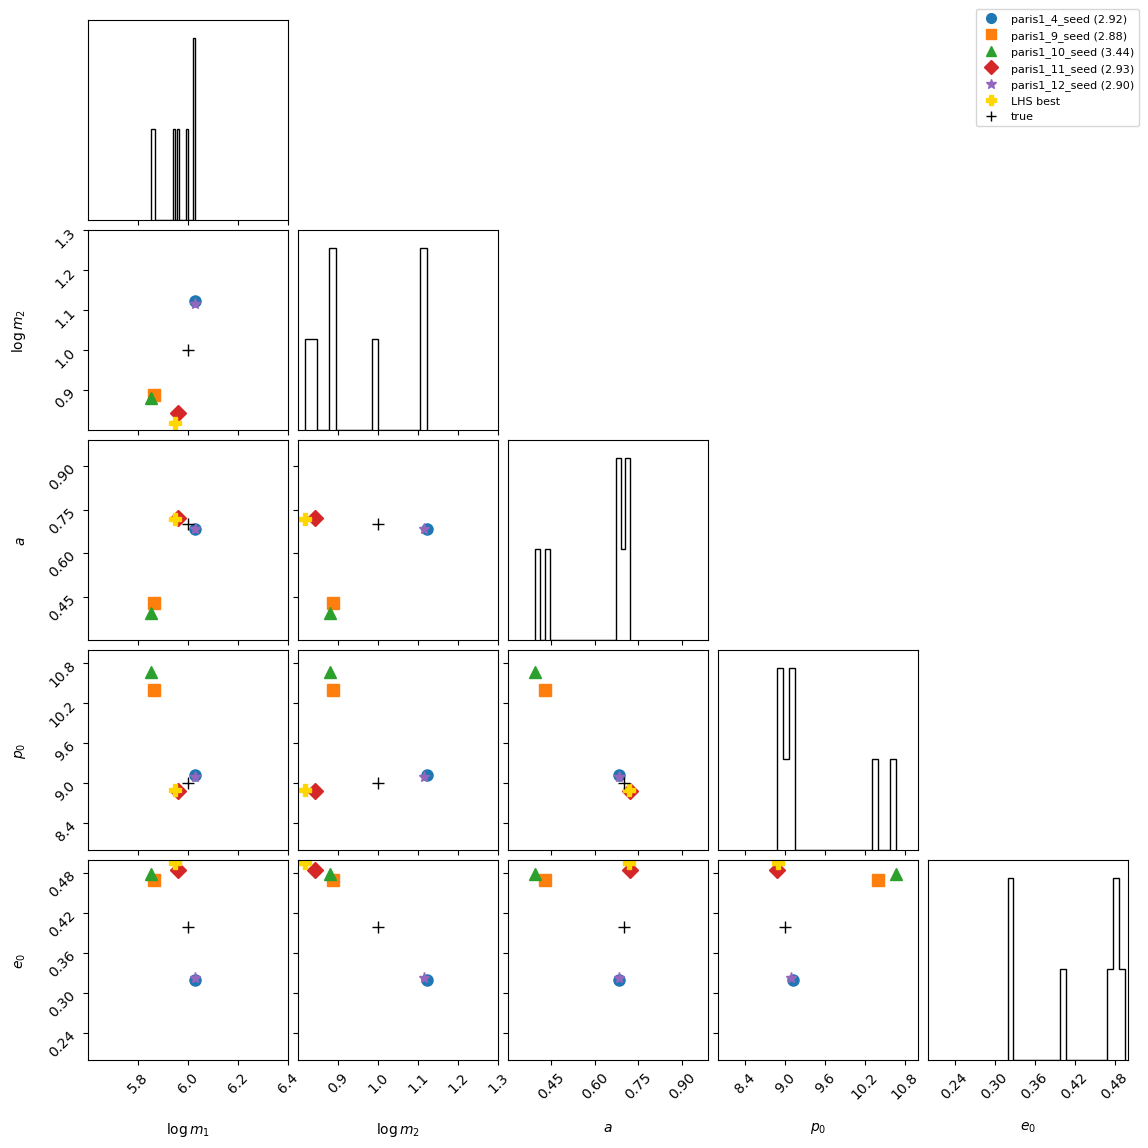

In [33]:
# Stack all points: runs + LHS best + true
all_pts = np.array([d['phys'] for d in results.values()] + [lhs_best_phys, true_params])

fig = corner.corner(all_pts, labels=labels, show_titles=False,
                    plot_datapoints=False, plot_density=False, plot_contours=False, ranges=ranges)

# Match colors to nproc plot: same default prop cycle, keyed by run name
_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
_name_color = {name: _cycle[i % len(_cycle)] for i, name in enumerate(files)}
colors  = [_name_color.get(name, _cycle[i % len(_cycle)]) for i, name in enumerate(results)] + ['gold', 'black']
_run_markers = ['o', 's', '^', 'D', '*', 'h', 'v', '<', '>']
markers = [_run_markers[i % len(_run_markers)] for i in range(len(results))] + ['P', '+']

for (name, pt), c, mk in zip(plot_points.items(), colors, markers):
    corner.overplot_points(fig, pt.reshape(1, -1), color=c, marker=mk, ms=8)

# Re-enforce ranges after overplot_points resets them
axes = np.array(fig.axes).reshape((ndim, ndim))
for row in range(ndim):
    for col in range(ndim):
        if col <= row:
            axes[row, col].set_xlim(ranges[col])
        if col < row:
            axes[row, col].set_ylim(ranges[row])

from matplotlib.lines import Line2D
handles = [Line2D([0],[0], color=c, marker=mk, ls='', ms=7,
                label=f"{name} ({results[name]['logden']:.2f})" if name in results else name)
            for (name, _), c, mk in zip(plot_points.items(), colors, markers)]
fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=8)
# fig.suptitle('Max-ld point per run [:3900] | LHS best | true', fontsize=10)
# plt.savefig('corner_maxld_trunc3900.png', dpi=150, bbox_inches='tight')
plt.show()

# connection plot

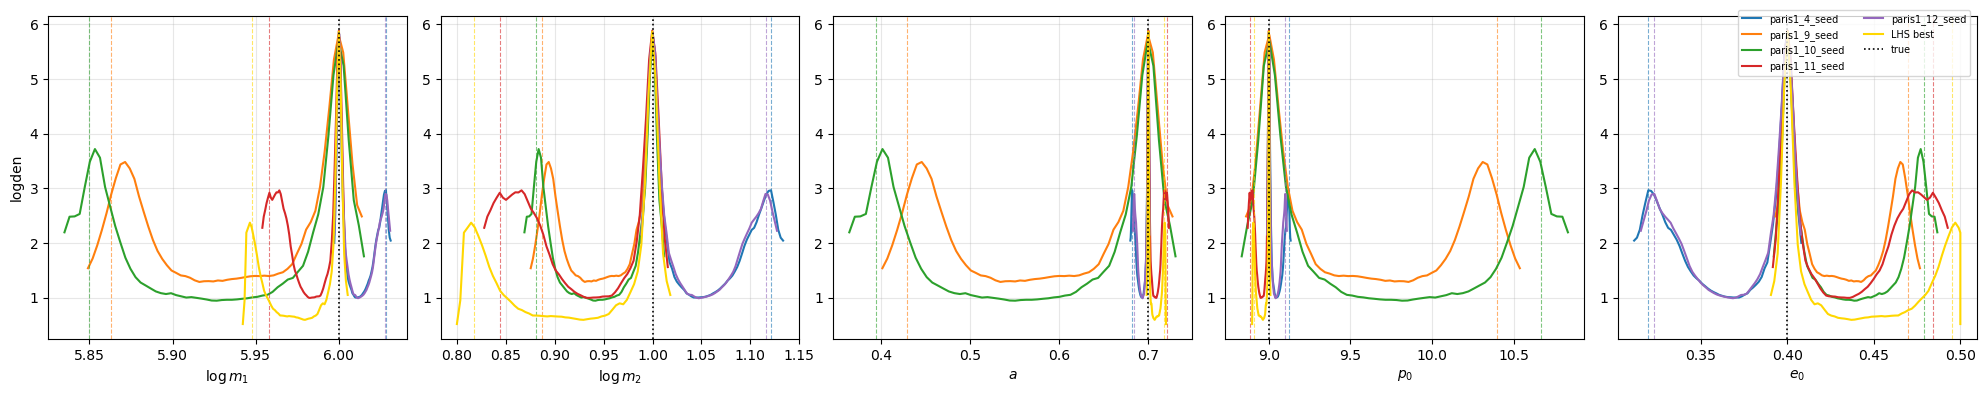

In [34]:
_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
_name_color = {name: _cycle[i % len(_cycle)] for i, name in enumerate(files)}

N_SCAN = 60

fig, axes = plt.subplots(1, ndim, figsize=(4*ndim, 4), sharey=False)

for name, pt in plot_points.items():
    if name == 'true':
        continue
    c  = _name_color.get(name, 'gold' if name == 'LHS best' else 'black')
    mk = markers[list(plot_points.keys()).index(name)]

    direction = true_params - pt
    if np.linalg.norm(direction) == 0:
        continue

    t_vals = np.linspace(-0.1, 1.1, N_SCAN)
    line_pts = pt[np.newaxis, :] + t_vals[:, np.newaxis] * direction[np.newaxis, :]
    for dim, (lo, hi) in enumerate(ranges):
        line_pts[:, dim] = np.clip(line_pts[:, dim], lo, hi)

    lds = log_density(line_pts)

    for dim, ax in enumerate(axes):
        ax.plot(line_pts[:, dim], lds, color=c, lw=1.5,
                label=name if dim == 0 else None)
        ax.axvline(pt[dim], color=c, lw=0.8, ls='--', alpha=0.6)

for dim, ax in enumerate(axes):
    ax.axvline(true_params[dim], color='black', lw=1.2, ls=':', label='true' if dim == 0 else None)
    ax.set_xlabel(labels[dim], fontsize=10)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('logden', fontsize=10)
fig.legend(*axes[0].get_legend_handles_labels(),
           loc='upper right', bbox_to_anchor=(0.99, 0.99), fontsize=7, ncol=2)
# fig.suptitle('1-D log-density scan: each point → true', fontsize=11)
plt.tight_layout()
plt.show()